<a href="https://colab.research.google.com/github/BalamuruganR2004/Data-Science-Project/blob/main/Basic_stats_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# First cell - Libraries import pannu
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [2]:
# Second cell - CSV file upload pannu
from google.colab import files
uploaded = files.upload()  # Inga un CSV file-a select pannu

Saving sales_data_with_discounts.csv to sales_data_with_discounts.csv


In [3]:
# Third cell - Data load pannu
df = pd.read_csv('sales_data_with_discounts.csv')

# Basic info paaru
print("📊 Dataset Shape:", df.shape)
print("\n📋 Column Names:")
print(df.columns.tolist())
print("\n🔍 First 5 Rows:")
df.head()

📊 Dataset Shape: (450, 13)

📋 Column Names:
['Date', 'Day', 'SKU', 'City', 'Volume', 'BU', 'Brand', 'Model', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']

🔍 First 5 Rows:


,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [4]:
numerical_cols = ['Volume', 'Avg Price', 'Total Sales Value',
                  'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']

print("="*60)
print("📈 DESCRIPTIVE STATISTICS - NUMERICAL COLUMNS")
print("="*60)

for col in numerical_cols:
    print(f"\n🔹 {col}")
    print("-"*40)
    data = df[col]
    print(f"   Mean (Sarasari):     {data.mean():,.2f}")
    print(f"   Median (Naduppu):    {data.median():,.2f}")
    print(f"   Mode (Athigam):      {data.mode().iloc[0]:,.2f}")
    print(f"   Std Dev (Vilagal):   {data.std():,.2f}")
    print(f"   Min:                 {data.min():,.2f}")
    print(f"   Max:                 {data.max():,.2f}")
    print(f"   Skewness:            {data.skew():.2f}")

📈 DESCRIPTIVE STATISTICS - NUMERICAL COLUMNS

🔹 Volume
----------------------------------------
   Mean (Sarasari):     5.07
   Median (Naduppu):    4.00
   Mode (Athigam):      3.00
   Std Dev (Vilagal):   4.23
   Min:                 1.00
   Max:                 31.00
   Skewness:            2.73

🔹 Avg Price
----------------------------------------
   Mean (Sarasari):     10,453.43
   Median (Naduppu):    1,450.00
   Mode (Athigam):      400.00
   Std Dev (Vilagal):   18,079.90
   Min:                 290.00
   Max:                 60,100.00
   Skewness:            1.91

🔹 Total Sales Value
----------------------------------------
   Mean (Sarasari):     33,812.84
   Median (Naduppu):    5,700.00
   Mode (Athigam):      24,300.00
   Std Dev (Vilagal):   50,535.07
   Min:                 400.00
   Max:                 196,400.00
   Skewness:            1.53

🔹 Discount Rate (%)
----------------------------------------
   Mean (Sarasari):     15.16
   Median (Naduppu):    16.58
   Mod

In [5]:
print("\n📋 COMPLETE SUMMARY TABLE:")
df[numerical_cols].describe().round(2)


📋 COMPLETE SUMMARY TABLE:


,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
count,450.00,450.00,450.00,450.00,450.00,450.00
mean,5.07,10453.43,33812.84,15.16,3346.50,30466.34
std,4.23,18079.90,50535.07,4.22,4509.90,46358.66
min,1.00,290.00,400.00,5.01,69.18,326.97
25%,3.00,465.00,2700.00,13.97,460.46,2202.21
50%,4.00,1450.00,5700.00,16.58,988.93,4677.79
75%,6.00,10100.00,53200.00,18.11,5316.50,47847.91
max,31.00,60100.00,196400.00,19.99,25738.02,179507.48


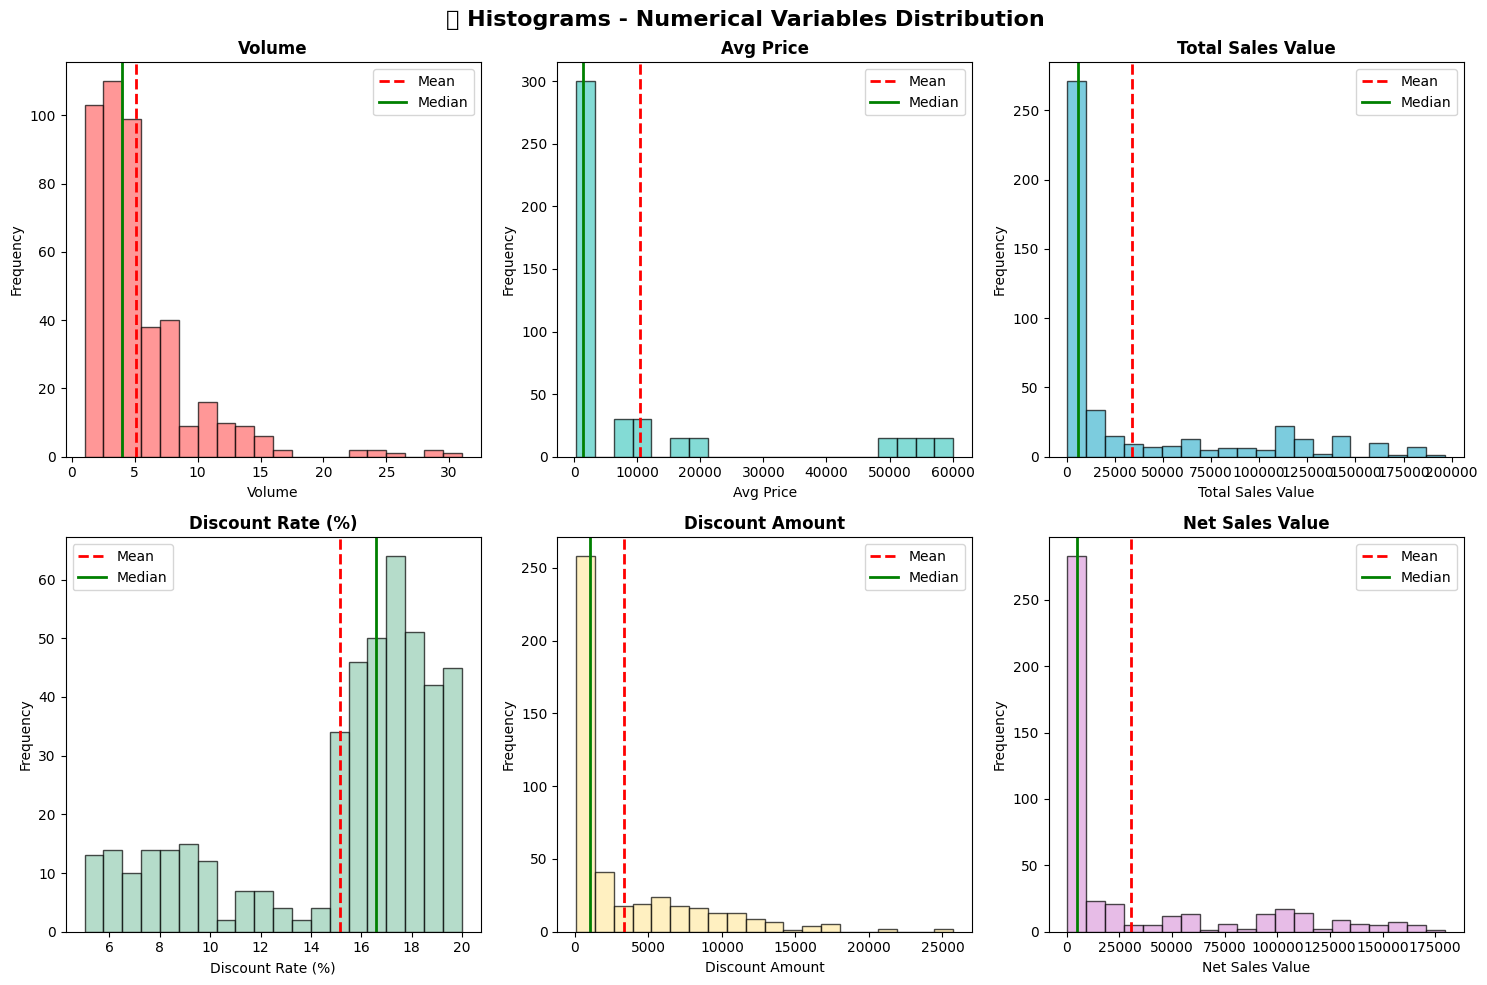


📝 HISTOGRAM INFERENCE:
• Volume - Right skewed (positive skew), most sales are low volume
• Avg Price - Right skewed, majority products are low-priced (FMCG)
• Discount Rate - Left skewed, most discounts are between 15-20%


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('📊 Histograms - Numerical Variables Distribution', fontsize=16, fontweight='bold')

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']

for idx, col in enumerate(numerical_cols):
    ax = axes[idx // 3, idx % 3]
    ax.hist(df[col], bins=20, color=colors[idx], edgecolor='black', alpha=0.7)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean')
    ax.axvline(df[col].median(), color='green', linestyle='-', linewidth=2, label=f'Median')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()

print("\n📝 HISTOGRAM INFERENCE:")
print("• Volume - Right skewed (positive skew), most sales are low volume")
print("• Avg Price - Right skewed, majority products are low-priced (FMCG)")
print("• Discount Rate - Left skewed, most discounts are between 15-20%")

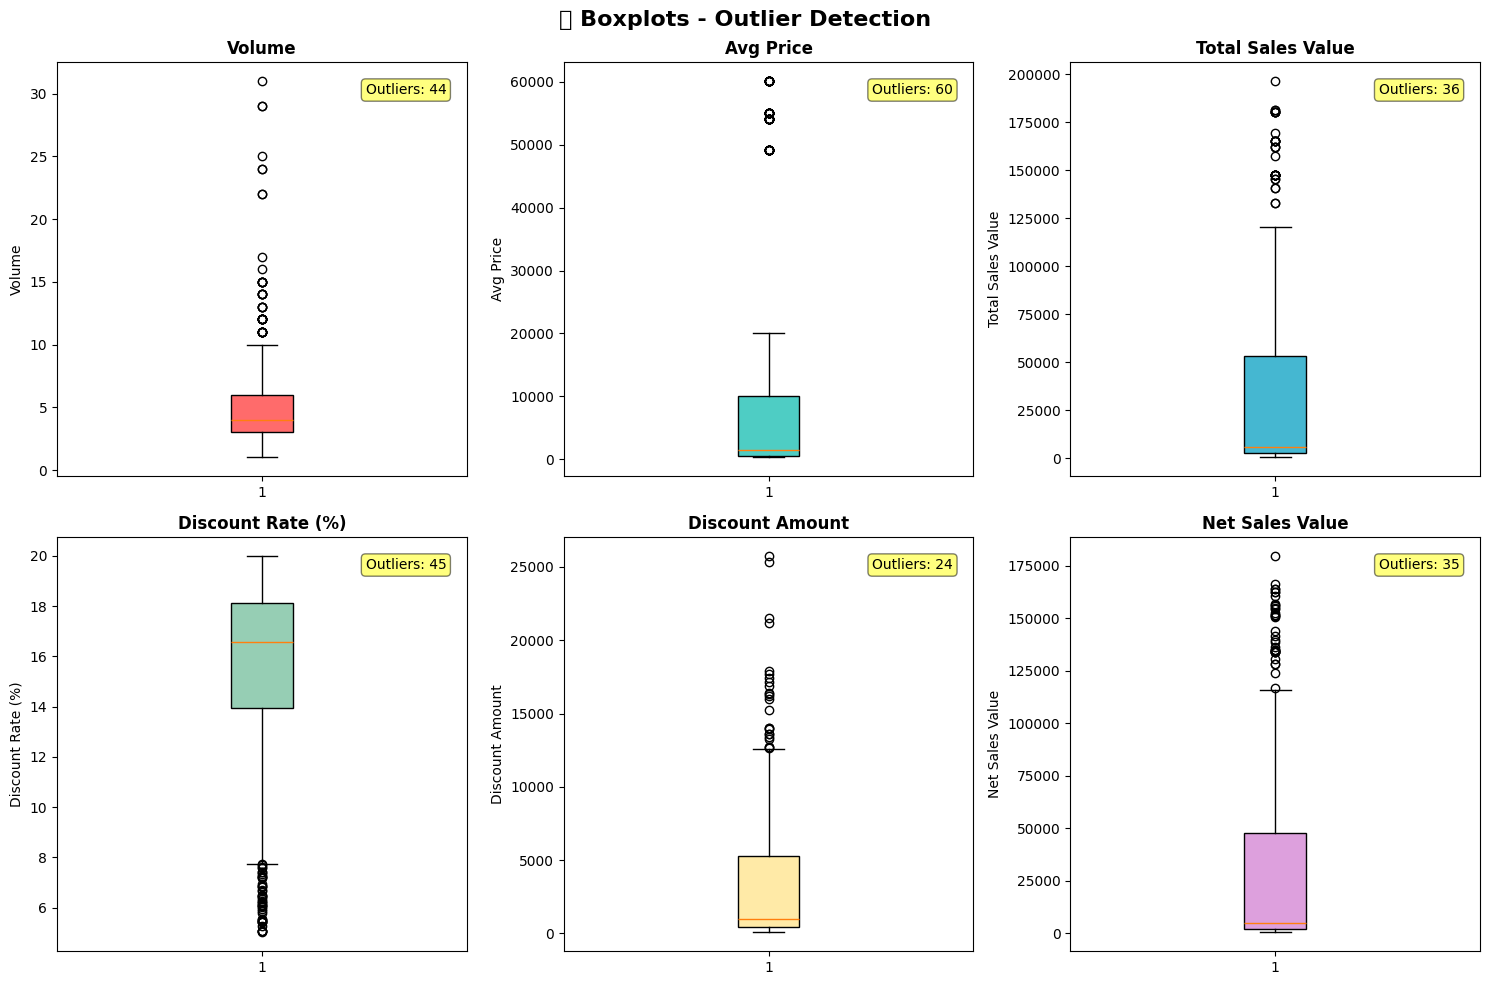


📝 BOXPLOT INFERENCE:
• Volume has outliers indicating some days with unusually high sales
• Sales values show outliers due to expensive Mobile products


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('📦 Boxplots - Outlier Detection', fontsize=16, fontweight='bold')

for idx, col in enumerate(numerical_cols):
    ax = axes[idx // 3, idx % 3]
    box = ax.boxplot(df[col], patch_artist=True)
    box['boxes'][0].set_facecolor(colors[idx])
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_ylabel(col)

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)][col]
    ax.text(0.95, 0.95, f'Outliers: {len(outliers)}', transform=ax.transAxes,
            fontsize=10, va='top', ha='right',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n📝 BOXPLOT INFERENCE:")
print("• Volume has outliers indicating some days with unusually high sales")
print("• Sales values show outliers due to expensive Mobile products")

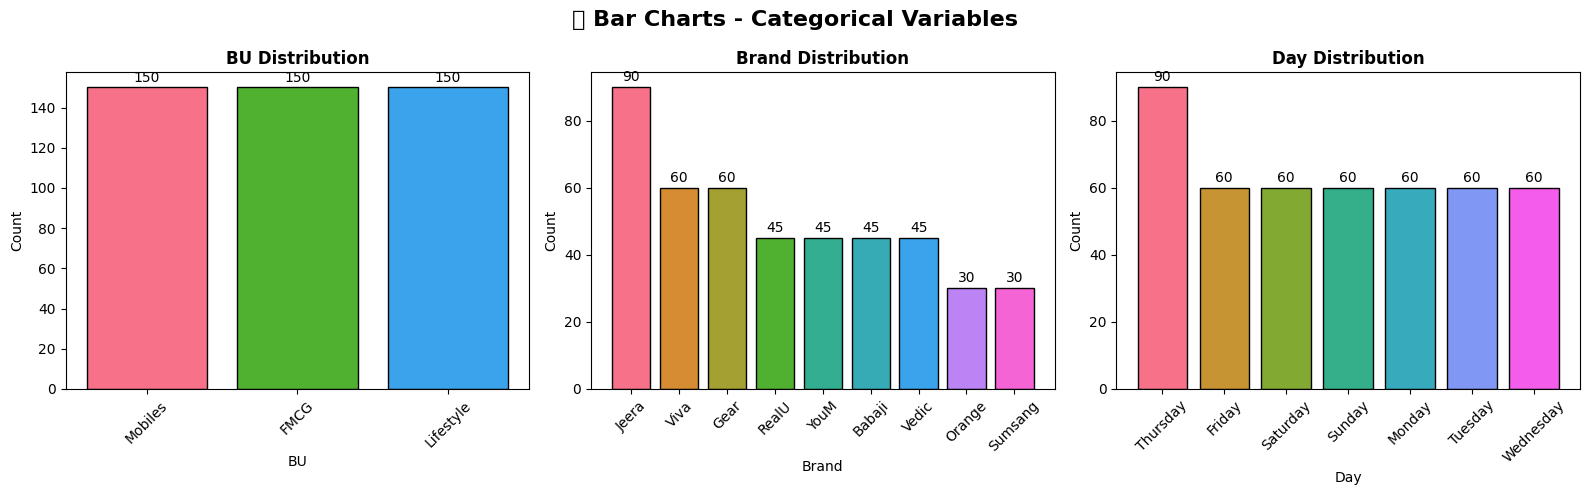


📝 BAR CHART INFERENCE:
• 3 Business Units: Mobiles, FMCG, Lifestyle - each has 150 records
• Jeera brand has highest count (90), Orange/Sumsang lowest (30)
• Thursday has more records (90) than other days (60 each)


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('📊 Bar Charts - Categorical Variables', fontsize=16, fontweight='bold')

categorical_cols = ['BU', 'Brand', 'Day']

for idx, col in enumerate(categorical_cols):
    ax = axes[idx]
    value_counts = df[col].value_counts()
    bars = ax.bar(value_counts.index, value_counts.values,
                  color=sns.color_palette("husl", len(value_counts)), edgecolor='black')
    ax.set_title(f'{col} Distribution', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

    for bar, val in zip(bars, value_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(val), ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\n📝 BAR CHART INFERENCE:")
print("• 3 Business Units: Mobiles, FMCG, Lifestyle - each has 150 records")
print("• Jeera brand has highest count (90), Orange/Sumsang lowest (30)")
print("• Thursday has more records (90) than other days (60 each)")

In [9]:
print("="*60)
print("📐 STANDARDIZATION (Z-SCORE NORMALIZATION)")
print("="*60)
print("\n📌 Formula: z = (x - μ) / σ")
print("   x = original value")
print("   μ = mean (sarasari)")
print("   σ = standard deviation")
print("\n🎯 Purpose: Scale all features to mean=0, std=1 for ML algorithms")

print("\n📊 BEFORE STANDARDIZATION:")
print(df[numerical_cols].describe().round(2))

df_std = df.copy()
for col in numerical_cols:
    mean = df[col].mean()
    std = df[col].std()
    df_std[col + '_standardized'] = (df[col] - mean) / std

std_cols = [col + '_standardized' for col in numerical_cols]
print("\n📊 AFTER STANDARDIZATION:")
print(df_std[std_cols].describe().round(4))

print("\n📋 COMPARISON - First 5 rows:")
print("\nVolume (Original):", df['Volume'].head().values)
print("Volume (Standardized):", df_std['Volume_standardized'].head().values.round(4))

📐 STANDARDIZATION (Z-SCORE NORMALIZATION)

📌 Formula: z = (x - μ) / σ
   x = original value
   μ = mean (sarasari)
   σ = standard deviation

🎯 Purpose: Scale all features to mean=0, std=1 for ML algorithms

📊 BEFORE STANDARDIZATION:
       Volume  Avg Price  Total Sales Value  Discount Rate (%)  \
count  450.00     450.00             450.00             450.00   
mean     5.07   10453.43           33812.84              15.16   
std      4.23   18079.90           50535.07               4.22   
min      1.00     290.00             400.00               5.01   
25%      3.00     465.00            2700.00              13.97   
50%      4.00    1450.00            5700.00              16.58   
75%      6.00   10100.00           53200.00              18.11   
max     31.00   60100.00          196400.00              19.99   

       Discount Amount  Net Sales Value  
count           450.00           450.00  
mean           3346.50         30466.34  
std            4509.90         46358.66  
min

In [10]:
print("="*60)
print("🔢 ONE-HOT ENCODING (DUMMY VARIABLES)")
print("="*60)
print("\n📌 Categorical data-va binary (0/1) columns-a convert pannurom")
print("🎯 Purpose: ML algorithms categorical data puriyaathu, numbers venum")

categorical_for_encoding = ['Day', 'BU', 'Brand']

print("\n📊 BEFORE ENCODING:")
print(f"Total columns: {len(df.columns)}")
for col in categorical_for_encoding:
    print(f"\n{col} unique values: {df[col].unique()}")

df_encoded = pd.get_dummies(df, columns=categorical_for_encoding, dtype=int)

print("\n📊 AFTER ENCODING:")
print(f"Total columns: {len(df_encoded.columns)}")

new_cols = [c for c in df_encoded.columns if any(cat in c for cat in categorical_for_encoding)]
print(f"\nNew dummy columns created ({len(new_cols)}):")
for col in new_cols:
    print(f"  • {col}")

print("\n📋 SAMPLE ENCODED DATA (Day columns):")
day_cols = [c for c in df_encoded.columns if c.startswith('Day_')]
print(df_encoded[day_cols].head())

🔢 ONE-HOT ENCODING (DUMMY VARIABLES)

📌 Categorical data-va binary (0/1) columns-a convert pannurom
🎯 Purpose: ML algorithms categorical data puriyaathu, numbers venum

📊 BEFORE ENCODING:
Total columns: 13

Day unique values: ['Thursday' 'Friday' 'Saturday' 'Sunday' 'Monday' 'Tuesday' 'Wednesday']

BU unique values: ['Mobiles' 'FMCG' 'Lifestyle']

Brand unique values: ['RealU' 'YouM' 'Sumsang' 'Orange' 'Babaji' 'Vedic' 'Gear' 'Jeera' 'Viva']

📊 AFTER ENCODING:
Total columns: 29

New dummy columns created (19):
  • Day_Friday
  • Day_Monday
  • Day_Saturday
  • Day_Sunday
  • Day_Thursday
  • Day_Tuesday
  • Day_Wednesday
  • BU_FMCG
  • BU_Lifestyle
  • BU_Mobiles
  • Brand_Babaji
  • Brand_Gear
  • Brand_Jeera
  • Brand_Orange
  • Brand_RealU
  • Brand_Sumsang
  • Brand_Vedic
  • Brand_Viva
  • Brand_YouM

📋 SAMPLE ENCODED DATA (Day columns):
   Day_Friday  Day_Monday  Day_Saturday  Day_Sunday  Day_Thursday  \
0           0           0             0           0             1   
1     

In [11]:
print("="*60)
print("📝 CONCLUSION & KEY FINDINGS")
print("="*60)

print("""
1️⃣ DESCRIPTIVE ANALYTICS:
   • Total 450 records, 15 days of sales data
   • Average Volume: 5 units, Average Net Sales: ₹30,466
   • Discount rate ranges from 5% to 20% (average 15%)

2️⃣ DATA DISTRIBUTION (Histograms):
   • Volume, Price, Sales - Right skewed (positively skewed)
   • Discount Rate - Left skewed (negatively skewed)
   • Most products are low-priced FMCG items

3️⃣ OUTLIERS (Boxplots):
   • Volume has significant outliers (high sales days)
   • Sales values show outliers due to expensive Mobile products

4️⃣ CATEGORICAL ANALYSIS (Bar Charts):
   • 3 BUs contribute equally (150 records each)
   • Jeera brand dominates in Lifestyle category
   • Thursday has more transactions

5️⃣ STANDARDIZATION:
   • All numerical features scaled to mean=0, std=1
   • Ready for distance-based ML algorithms (KNN, SVM, etc.)

6️⃣ ONE-HOT ENCODING:
   • 19 new dummy variables created
   • Categorical data now ML-ready

✅ Dataset is now preprocessed and ready for Machine Learning!
""")

📝 CONCLUSION & KEY FINDINGS

1️⃣ DESCRIPTIVE ANALYTICS:
   • Total 450 records, 15 days of sales data
   • Average Volume: 5 units, Average Net Sales: ₹30,466
   • Discount rate ranges from 5% to 20% (average 15%)

2️⃣ DATA DISTRIBUTION (Histograms):
   • Volume, Price, Sales - Right skewed (positively skewed)
   • Discount Rate - Left skewed (negatively skewed)
   • Most products are low-priced FMCG items

3️⃣ OUTLIERS (Boxplots):
   • Volume has significant outliers (high sales days)
   • Sales values show outliers due to expensive Mobile products

4️⃣ CATEGORICAL ANALYSIS (Bar Charts):
   • 3 BUs contribute equally (150 records each)
   • Jeera brand dominates in Lifestyle category
   • Thursday has more transactions

5️⃣ STANDARDIZATION:
   • All numerical features scaled to mean=0, std=1
   • Ready for distance-based ML algorithms (KNN, SVM, etc.)

6️⃣ ONE-HOT ENCODING:
   • 19 new dummy variables created
   • Categorical data now ML-ready

✅ Dataset is now preprocessed and ready 

In [12]:
df_final = df_std.copy()
df_final = pd.get_dummies(df_final, columns=['Day', 'BU', 'Brand'], dtype=int)
df_final.to_csv('processed_sales_data.csv', index=False)

from google.colab import files
files.download('processed_sales_data.csv')

print("✅ Processed data downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Processed data downloaded!
